In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

%matplotlib inline

In [3]:
df = pd.read_csv("emails.csv.zip")
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
the,5172.0,6.640565,11.745009,0.0,0.0,3.0,8.0,210.0
to,5172.0,6.188128,9.534576,0.0,1.0,3.0,7.0,132.0
ect,5172.0,5.143852,14.101142,1.0,1.0,1.0,4.0,344.0
and,5172.0,3.075599,6.045970,0.0,0.0,1.0,3.0,89.0
for,5172.0,3.124710,4.680522,0.0,1.0,2.0,4.0,47.0
...,...,...,...,...,...,...,...,...
military,5172.0,0.006574,0.138908,0.0,0.0,0.0,0.0,4.0
allowing,5172.0,0.004060,0.072145,0.0,0.0,0.0,0.0,3.0
ff,5172.0,0.914733,2.780203,0.0,0.0,0.0,1.0,114.0
dry,5172.0,0.006961,0.098086,0.0,0.0,0.0,0.0,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [6]:
df.describe(include='object').T

,count,unique,top,freq
Email No.,5172,5172,Email 5172,1


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df.types

,types
0,0
1,0
2,0
3,0
4,0
...,...
5167,0
5168,0
5169,0
5170,0


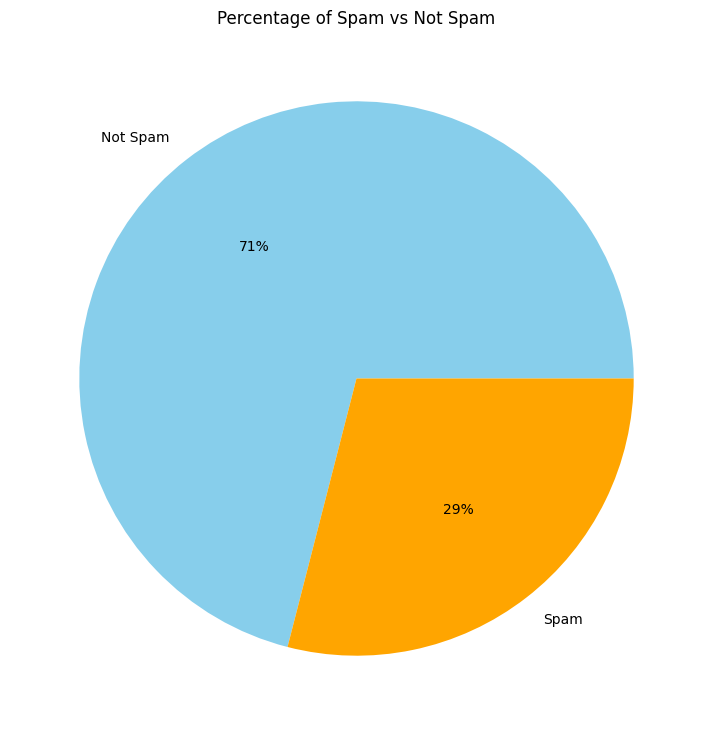

In [9]:
counts = df["Prediction"].value_counts(normalize=True)

plt.figure(figsize=(10,9))
plt.pie(
    counts.values * 100,
    labels=["Not Spam", "Spam"],
    autopct="%1.0f%%",
    colors = ['skyblue','orange']
)
plt.title("Percentage of Spam vs Not Spam")
plt.show()

In [10]:
x = df.drop(['Email No.','Prediction'], axis=1)
y = df['Prediction']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=26)

logistic regression

In [12]:
model = LogisticRegression(max_iter=200)
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [13]:
y_pred = model.predict(x_test)

In [14]:
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred))
print('Accuracy Score')
print(accuracy_score(y_test, y_pred))

Confusion Matrix
[[727  15]
 [ 16 277]]
Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       742
           1       0.95      0.95      0.95       293

    accuracy                           0.97      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.97      0.97      0.97      1035

Accuracy Score
0.970048309178744


In [15]:
model_nb = MultinomialNB() # using Multinomial Naive Bayes for comparison
model_nb.fit(x_train, y_train)

MultinomialNB()

In [16]:
y_pred = model_nb.predict(x_test)

In [17]:
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))
print('Classification Report')
print(classification_report(y_test, y_pred))
print('Accuracy Score')
print(accuracy_score(y_test, y_pred))

Confusion Matrix
[[693  49]
 [ 19 274]]
Classification Report
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       742
           1       0.85      0.94      0.89       293

    accuracy                           0.93      1035
   macro avg       0.91      0.93      0.92      1035
weighted avg       0.94      0.93      0.94      1035

Accuracy Score
0.9342995169082126


In [18]:
feature_importance = pd.Series(model.coef_[0], index=x.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
only,0.707082
z,0.700104
http,0.699686
ali,0.691259
ad,0.613675
alt,0.609582
pt,0.588959
mo,0.581802
gra,0.579680
money,0.574370
